In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [5]:
DATASET_DIR = Path("/kaggle/input/datasets/malakdiab04/hieroglyph-classification-augmented-trial-2")

TRAIN_DIR = DATASET_DIR / "train/train"
VAL_DIR = DATASET_DIR / "val/val"
TEST_DIR = DATASET_DIR / "test/test"

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

EPOCHS_HEAD = 10
EPOCHS_FINE = 20

LR_HEAD = 1e-3
LR_FINE = 3e-6

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
val_classes = sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()])
test_classes = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Train classes:", len(train_classes))
print("Val classes:", len(val_classes))
print("Test classes:", len(test_classes))

print("Example classes:", train_classes[:20])

Train exists: True
Val exists: True
Test exists: True
Train classes: 718
Val classes: 705
Test classes: 562
Example classes: ['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A2', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27']


In [7]:
def count_images_per_class(split_dir):
    rows = []
    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}
    
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        
        count = sum(
            1 for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in image_exts
        )
        
        rows.append({
            "label": class_dir.name,
            "count": count
        })
    
    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

In [8]:
train_counts = count_images_per_class(TRAIN_DIR)
val_counts = count_images_per_class(VAL_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Train images:", train_counts["count"].sum())
print("Val images:", val_counts["count"].sum())
print("Test images:", test_counts["count"].sum())

display(train_counts.head(20))
display(train_counts.tail(20))

Train images: 45325
Val images: 2686
Test images: 2582


,label,count
0,O4,200
1,Y5,200
2,D21,200
3,S34,200
4,A1,200
5,X1,200
6,G17,200
7,G43,200
8,M17,200
9,V30,200


,label,count
698,S5,30
699,N13,30
700,O26,30
701,P11,30
702,S7,30
703,A33,30
704,O44,30
705,O64,15
706,G144,15
707,M163,15


In [9]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

class_names = train_classes
NUM_CLASSES = len(class_names)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("NUM_CLASSES:", NUM_CLASSES)
print("Example mapping:", list(class_to_idx.items())[:10])

NUM_CLASSES: 718
Example mapping: [('A1', 0), ('A10', 1), ('A11', 2), ('A12', 3), ('A13', 4), ('A14', 5), ('A15', 6), ('A16', 7), ('A17', 8), ('A18', 9)]


In [10]:
def build_split_df(split_dir, class_to_idx):
    rows = []
    
    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue
        
        label = class_dir.name
        
        if label not in class_to_idx:
            continue
        
        label_idx = class_to_idx[label]
        
        for img_path in class_dir.iterdir():
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
                rows.append({
                    "filepath": str(img_path),
                    "label": label,
                    "label_idx": label_idx
                })
    
    return pd.DataFrame(rows)

In [11]:
train_df = build_split_df(TRAIN_DIR, class_to_idx)
val_df = build_split_df(VAL_DIR, class_to_idx)
test_df = build_split_df(TEST_DIR, class_to_idx)

print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

print("Train classes:", train_df["label"].nunique())
print("Val classes:", val_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

display(train_df.head())

Train images: 45325
Val images: 2686
Test images: 2582
Train classes: 718
Val classes: 705
Test classes: 562


,filepath,label,label_idx
0,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
1,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
2,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
3,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
4,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614


In [12]:
def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label_idx"].values.astype(np.int32)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    
    return ds

In [13]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print(train_ds)

I0000 00:00:1777399090.038781      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [14]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels example:", labels[:10].numpy())
print("Class names example:", [class_names[i] for i in labels[:10].numpy()])

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels example: [543 462 631  81 694 120 375 366 286 349]
Class names example: ['S43', 'O9', 'V13', 'D1', 'X6', 'D45', 'N23', 'N15', 'H8', 'M4']


Total classes: 718
Total images: 45325


label
G43    200
Q3     200
F31    200
F35    200
M17    200
V30    200
O49    200
S29    200
O34    200
D36    200
Name: count, dtype: int64

label
P13     15
O62     15
O206    15
O307    15
O292    15
O54     15
A282    15
P36     15
F102    15
D154    15
Name: count, dtype: int64

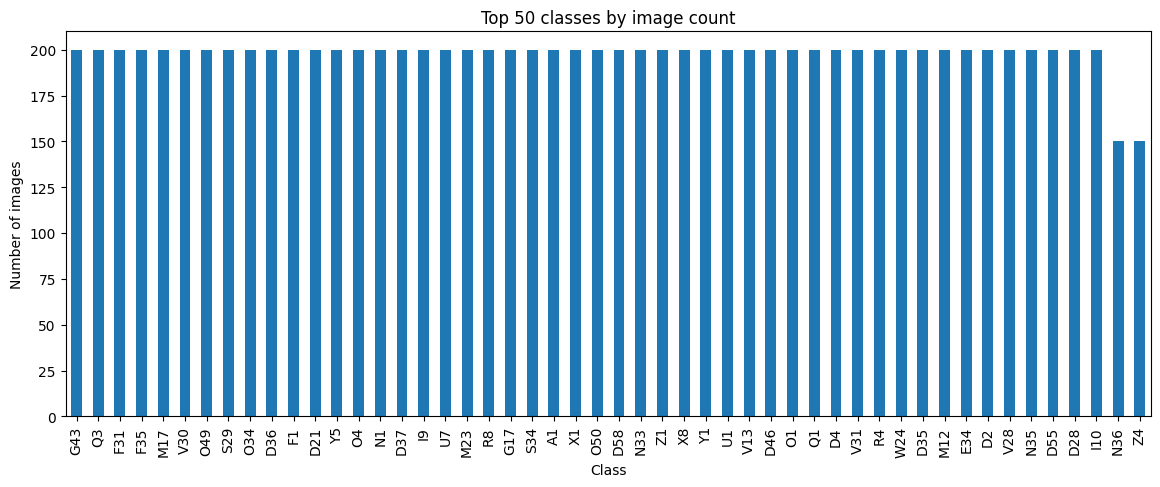

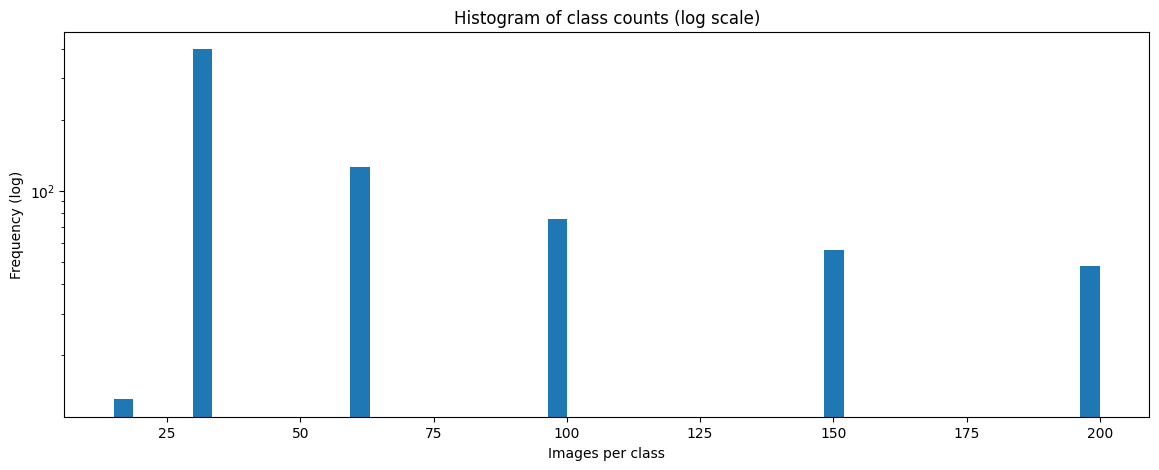

In [15]:
train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Total classes:", len(train_class_counts))
print("Total images:", train_class_counts.sum())

display(train_class_counts.head(10))
display(train_class_counts.tail(10))

# Plot (top 50 classes)
plt.figure(figsize=(14,5))
train_class_counts.head(50).plot(kind="bar")
plt.title("Top 50 classes by image count")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.xticks(rotation=90)
plt.show()

# Plot (log scale full distribution)
plt.figure(figsize=(14,5))
train_class_counts.plot(kind="hist", bins=50)
plt.yscale("log")
plt.title("Histogram of class counts (log scale)")
plt.xlabel("Images per class")
plt.ylabel("Frequency (log)")
plt.show()

In [16]:
freq_series = train_class_counts.value_counts().sort_index()

freq = pd.DataFrame({
    "images_per_class": freq_series.index,
    "num_classes": freq_series.values
})

display(freq)

,images_per_class,num_classes
0,15,13
1,30,399
2,60,126
3,100,76
4,150,56
5,200,48


In [17]:
max_count = train_class_counts.max()
min_count = train_class_counts.min()

print("Max:", max_count)
print("Min:", min_count)
print("Ratio:", max_count / min_count)

Max: 200
Min: 15
Ratio: 13.333333333333334


In [18]:
train_label_indices = train_df["label_idx"].values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_label_indices
)

# soften weights so they do not overcorrect
weights = np.sqrt(weights)

class_weights = {i: float(w) for i, w in enumerate(weights)}

print("Min class weight:", min(class_weights.values()))
print("Max class weight:", max(class_weights.values()))
print("Example weights:", list(class_weights.items())[:10])

Min class weight: 0.5618128734154959
Max class weight: 2.051450559109744
Example weights: [(0, 0.5618128734154959), (1, 1.450594601615434), (2, 1.450594601615434), (3, 1.450594601615434), (4, 1.450594601615434), (5, 1.025725279554872), (6, 1.025725279554872), (7, 1.450594601615434), (8, 1.025725279554872), (9, 1.450594601615434)]


In [19]:
online_aug = keras.Sequential([
    layers.RandomRotation(0.025),
    layers.RandomZoom(0.04),
    layers.RandomTranslation(0.025, 0.025),
    layers.RandomContrast(0.05),
], name="online_augmentation")

In [20]:
preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input

base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = online_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.35)(x)
x = layers.Dense(512,activation="relu",kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax",kernel_regularizer=keras.regularizers.l2(1e-4))(x)
model = keras.Model(inputs, outputs)

model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ online_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 718)            │       368,334 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,362,734 (81.49 MB)

 Trainable params: 1,027,790 (3.92 MB)

 Non-trainable params: 20,334,944 (77.57 MB)

### Head Stage

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        "best_head_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    )
]

In [23]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head,
    class_weight=class_weights
)

Epoch 1/10


E0000 00:00:1777399169.769791      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777399172.806936     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2299 - loss: 4.2271
Epoch 1: val_accuracy improved from -inf to 0.60238, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 177s 107ms/step - accuracy: 0.2300 - loss: 4.2262 - val_accuracy: 0.6024 - val_loss: 1.9834 - learning_rate: 0.0010
Epoch 2/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6038 - loss: 1.5830
Epoch 2: val_accuracy improved from 0.60238 to 0.63812, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 147s 103ms/step - accuracy: 0.6038 - loss: 1.5830 - val_accuracy: 0.6381 - val_loss: 1.8946 - learning_rate: 0.0010
Epoch 3/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6655 - loss: 1.4019
Epoch 3: val_accuracy improved from 0.63812 to 0.65934, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 147s 103ms/step - accuracy: 0.6655 - loss: 1.4019 - val_accuracy: 0.6593 - val_loss: 1.8745 - learning_rate: 0.0010
Epoch 4/10
1416/1417 ━━━

In [24]:
def plot_history(history, title="Training History"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()

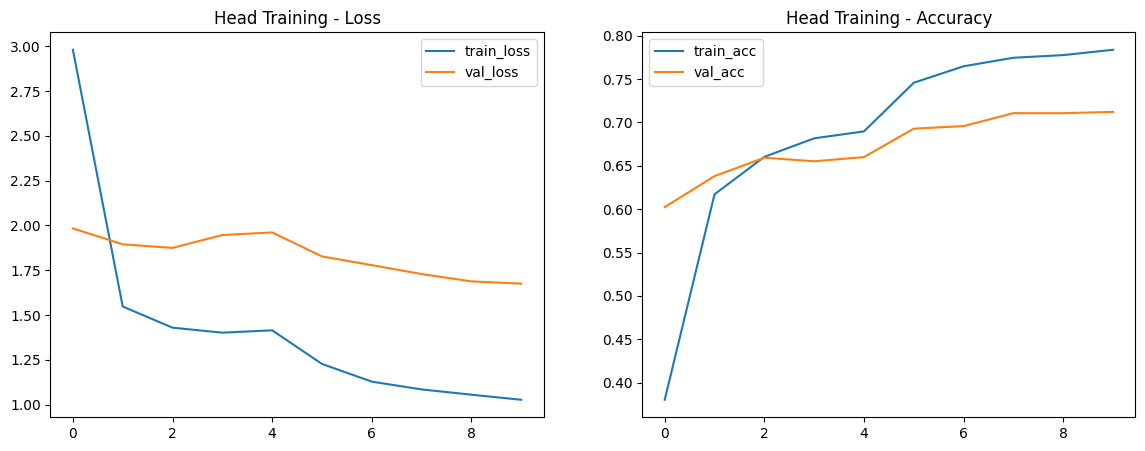

In [25]:
plot_history(history_head, title="Head Training")

In [29]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [30]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

Accuracy: 0.7060418280402788
Balanced Accuracy: 0.5343974012070511
Macro F1: 0.48279106063462357


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [31]:
top3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3.update_state(y_true, y_probs)
top5.update_state(y_true, y_probs)

print("Top-3 Accuracy:", top3.result().numpy())
print("Top-5 Accuracy:", top5.result().numpy())

Top-3 Accuracy: 0.8365608
Top-5 Accuracy: 0.87761426


### Fine-tuning

In [32]:
base_model.trainable = True

# Freeze early layers, fine-tune later layers only
fine_tune_at = int(len(base_model.layers) * 0.85)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total base layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total base layers: 513
Fine-tuning from layer: 436
Trainable layers: 77


In [33]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
callbacks_fine = [
    keras.callbacks.ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    )
]

In [35]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_fine,
    class_weight=class_weights
)

Epoch 1/20


E0000 00:00:1777401177.671099      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7098 - loss: 1.2744
Epoch 1: val_accuracy improved from -inf to 0.66456, saving model to best_finetuned_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 217s 132ms/step - accuracy: 0.7098 - loss: 1.2744 - val_accuracy: 0.6646 - val_loss: 1.8975 - learning_rate: 3.0000e-06
Epoch 2/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7443 - loss: 1.1467
Epoch 2: val_accuracy improved from 0.66456 to 0.68503, saving model to best_finetuned_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 183s 129ms/step - accuracy: 0.7443 - loss: 1.1467 - val_accuracy: 0.6850 - val_loss: 1.8415 - learning_rate: 3.0000e-06
Epoch 3/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7652 - loss: 1.0838
Epoch 3: val_accuracy improved from 0.68503 to 0.68913, saving model to best_finetuned_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 183s 129ms/step - accuracy: 0.7652 - loss: 1.0838 - val_accuracy: 0.6891 - val_loss: 1.8028 - learning_rate: 3.000

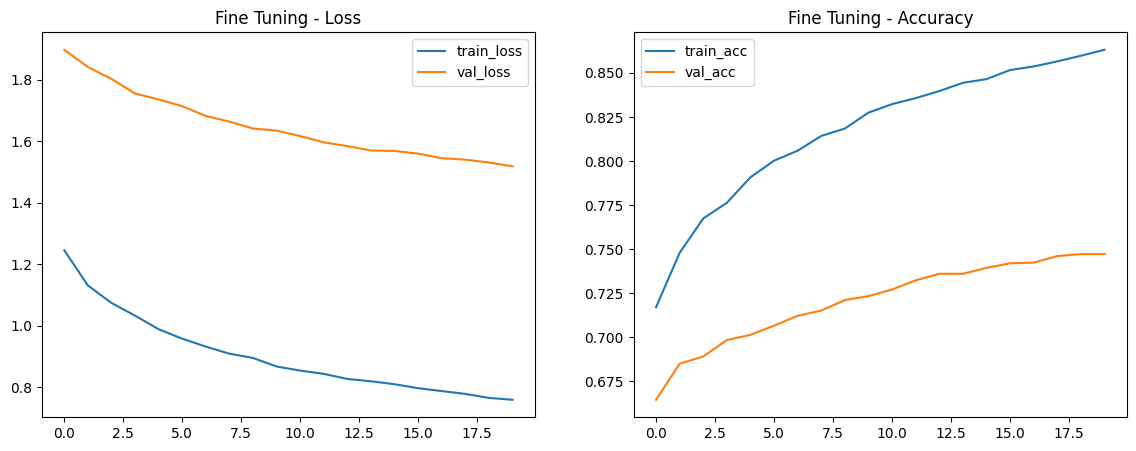

In [36]:
plot_history(history_fine, title="Fine Tuning")

In [37]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [38]:
print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

Test Accuracy: 0.7498063516653757
Balanced Accuracy: 0.5469288507330766
Macro F1: 0.4994050610805604


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [39]:
top3_2 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_2 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_2.update_state(y_true, y_probs)
top5_2.update_state(y_true, y_probs)

print("Top-3 Accuracy:", top3_2.result().numpy())
print("Top-5 Accuracy:", top5_2.result().numpy())

Top-3 Accuracy: 0.8636716
Top-5 Accuracy: 0.90240127


### Testing

In [42]:
model = keras.models.load_model("best_finetuned_model.keras")

In [46]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [40]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

Accuracy: 0.7498063516653757
Balanced Accuracy: 0.5469288507330766
Macro F1: 0.4994050610805604


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [41]:
top3_final = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_final = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_final.update_state(y_true, y_probs)
top5_final.update_state(y_true, y_probs)

print("Top-3 Accuracy:", top3_final.result().numpy())
print("Top-5 Accuracy:", top5_final.result().numpy())

Top-3 Accuracy: 0.8636716
Top-5 Accuracy: 0.90240127


In [42]:
model.save("hieroglyph_efficientnetv2s_final.keras")

label_map = pd.DataFrame({
    "class_index": list(range(len(class_names))),
    "gardiner_code": class_names
})

label_map.to_csv("label_map.csv", index=False)

print("Saved model and label map.")

Saved model and label map.


In [43]:
# Reverse Mapping
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

pd.DataFrame({
    "gardiner_code": list(class_to_idx.keys()),
    "class_index": list(class_to_idx.values())
}).to_csv("class_to_idx.csv", index=False)